 # 07 — Gaussian Smoothing Sensitivity Analysis



 This notebook evaluates whether Gaussian smoothing improves selected final functional classifiers from the model set.



 The notebook intentionally keeps the model set small and directly comparable to notebook 04.



 Compared representations:



 - raw L2-normalised sampled spectra;

 - Gaussian-smoothed sampled spectra with selected sigma values, followed by

   L2 normalisation.



 Compared models:



 - weighted kNN with standardized Euclidean distance;

 - functional logistic regression with L2 regularisation;

 - functional linear SVM.



 Main outputs:



 - `smoothing_fold_metrics.csv`;

 - `smoothing_summary.csv`;

 - `smoothing_summary_pretty.csv`;

 - `smoothing_delta_all_sigmas_minus_raw.csv`;

 - `smoothing_wilcoxon.csv`;

 - `smoothing_interpretability_payload.npz`;

 - SVG interpretability figures.

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import wilcoxon
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


 ## 1. Configuration



 This section defines input paths, output paths, model settings, smoothing values, and plot styling used throughout the notebook.

In [2]:
BASE_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "07_smoothing"
FIG_DIR = OUT_DIR

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SMOKE = False

SIGMAS = [0.0, 4.0, 6.0, 8.0, 10.0, 12.0]
BEST_SIGMA = 8.0

DISTANCE_K = 5

INNER_CV = 3
CS_GRID = np.logspace(-2, 2, 6)

LINEAR_MODELS = [
    {
        "family": "Functional linear",
        "method": "Functional logistic regression (L2)",
        "kind": "logreg_l2",
    },
    {
        "family": "Functional linear",
        "method": "Functional linear SVM",
        "kind": "linear_svm",
    },
]

COLOR_RAW = "#104A7E"
COLOR_SMOOTH = "#78003F"
COLOR_DARK = "#0D1530"
COLOR_GREY = "#8C8C8C"
COLOR_POS = "#6193CD"
COLOR_NEG = "#6F0037"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "figure.dpi": 120,
    }
)


 ## 2. Helper functions



 These functions handle file lookup, fold ordering, smoothing, normalisation, metric calculation, result summarisation, and figure styling.

In [ ]:
def find_first_existing(paths: list[Path]) -> Path | None:
    """Return the first existing path from a list of candidate paths.

    Parameters
    ----------
    paths:
        Candidate file paths to check.

    Returns
    -------
    Path | None
        First existing file path, or `None` if no candidate exists."""
    for path in paths:
        if path.exists():
            return path

    return None


def split_sort_key(split_name: str) -> tuple[int, int]:
    """Sort repeated CV split names by repetition and fold number.

    The expected split name format is similar to `rep0_fold0`.

    Parameters
    ----------
    split_name:
        Name of one repeated stratified CV split.

    Returns
    -------
    tuple[int, int]
        Parsed repetition and fold numbers."""
    rep = int(split_name.split("_")[0].replace("rep", ""))
    fold = int(split_name.split("_")[1].replace("fold", ""))

    return rep, fold


def mean_std_string(mean: float, std: float) -> str | float:
    """Format mean and standard deviation as a compact string.

    Parameters
    ----------
    mean:
        Mean metric value.
    std:
        Standard deviation of the metric.

    Returns
    -------
    str | float
        Formatted string, or `np.nan` if the mean is missing."""
    if pd.isna(mean):
        return np.nan

    std_value = 0.0 if pd.isna(std) else std
    return f"{mean:.4f} ± {std_value:.4f}"


def l2_normalise_rows(X: np.ndarray) -> np.ndarray:
    """Apply row-wise L2 normalisation to spectra.

    Each spectrum is divided by its L2 norm. Zero-norm rows are returned as
    zeros to avoid division errors.

    Parameters
    ----------
    X:
        Matrix where rows are spectra and columns are wavelengths.

    Returns
    -------
    np.ndarray
        L2-normalised matrix."""
    row_norm = np.linalg.norm(X, axis=1, keepdims=True)

    return np.divide(
        X,
        row_norm,
        out=np.zeros_like(X),
        where=row_norm > 1e-20,
    )


def gaussian_smoothing_matrix(
    wavelengths: np.ndarray,
    sigma: float,
) -> np.ndarray:
    """Build a row-normalised Gaussian smoothing matrix.

    Each row contains Gaussian weights centred at one wavelength. The rows are
    normalised so that each smoothed wavelength is a weighted average of the
    original spectrum.

    Parameters
    ----------
    wavelengths:
        Wavelength grid.
    sigma:
        Gaussian kernel width.

    Returns
    -------
    np.ndarray
        Row-normalised smoothing matrix."""
    weights = np.exp(
        -0.5 * ((wavelengths[:, None] - wavelengths[None, :]) / sigma) ** 2
    )
    weights /= weights.sum(axis=1, keepdims=True)

    return weights


def build_representation(
    X_raw: np.ndarray,
    wavelengths: np.ndarray,
    sigma: float,
) -> np.ndarray:
    """Build raw or Gaussian-smoothed L2-normalised spectra.

    If `sigma` is zero, the original raw spectra are used. Otherwise, Gaussian
    smoothing is applied first and L2 normalisation is applied afterwards.

    Parameters
    ----------
    X_raw:
        Raw sampled spectra.
    wavelengths:
        Wavelength grid.
    sigma:
        Smoothing parameter. Zero means no smoothing.

    Returns
    -------
    np.ndarray
        Raw or smoothed L2-normalised representation."""
    if sigma == 0:
        X_work = X_raw.copy()
    else:
        smoothing_matrix = gaussian_smoothing_matrix(wavelengths, sigma)
        X_work = X_raw @ smoothing_matrix.T

    return l2_normalise_rows(X_work)


def normalize_scores_train_ref(
    scores_te: np.ndarray,
    scores_tr: np.ndarray,
) -> np.ndarray:
    """Normalise scores using the training-score range.

    Test scores are scaled using only the training minimum and maximum. This
    avoids leakage from the test fold during threshold selection.

    Parameters
    ----------
    scores_te:
        Scores to normalise.
    scores_tr:
        Training scores used as the reference range.

    Returns
    -------
    np.ndarray
        Scores clipped to the interval `[0, 1]`."""
    lo = float(np.min(scores_tr))
    hi = float(np.max(scores_tr))

    if hi == lo:
        return np.full_like(scores_te, 0.5, dtype=np.float64)

    normalised = (scores_te - lo) / (hi - lo)
    return np.clip(normalised, 0.0, 1.0).astype(np.float64)


def pick_youden_threshold(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    grid_size: int = 200,
) -> float:
    """Choose a classification threshold by maximising Youden's J.

    Youden's J is defined as sensitivity + specificity - 1. The threshold is
    selected on training-fold scores and then applied to the test fold.

    Parameters
    ----------
    y_true:
        True binary labels.
    y_prob:
        Normalised scores or probabilities.
    grid_size:
        Number of candidate thresholds between 0 and 1.

    Returns
    -------
    float
        Selected threshold."""
    thresholds = np.linspace(0, 1, grid_size)
    best_j = -1.0
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(np.int64)
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1],
        ).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        youden_j = sensitivity + specificity - 1.0

        if youden_j > best_j:
            best_j = youden_j
            best_threshold = float(threshold)

    return best_threshold


def fold_metrics(
    y_true_te: np.ndarray,
    y_score_te: np.ndarray,
    y_true_tr: np.ndarray,
    y_score_tr: np.ndarray,
) -> dict[str, float]:
    """Calculate all fold-level classification metrics.

    PR-AUC and ROC-AUC are calculated directly from continuous scores. Binary
    metrics are calculated after selecting a Youden threshold on the training
    fold.

    Parameters
    ----------
    y_true_te:
        True labels for the test fold.
    y_score_te:
        Continuous model scores for the test fold.
    y_true_tr:
        True labels for the training fold.
    y_score_tr:
        Continuous model scores for the training fold.

    Returns
    -------
    dict[str, float]
        Fold-level metrics."""
    metrics = {
        "pr_auc": average_precision_score(y_true_te, y_score_te),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true_te, y_score_te))
    except ValueError:
        metrics["roc_auc"] = np.nan

    prob_tr = normalize_scores_train_ref(y_score_tr, y_score_tr)
    prob_te = normalize_scores_train_ref(y_score_te, y_score_tr)

    threshold = pick_youden_threshold(y_true_tr, prob_tr)
    y_pred = (prob_te >= threshold).astype(np.int64)

    metrics["youden_threshold"] = threshold
    metrics["sensitivity"] = recall_score(
        y_true_te,
        y_pred,
        pos_label=1,
        zero_division=0,
    )
    metrics["precision"] = precision_score(
        y_true_te,
        y_pred,
        pos_label=1,
        zero_division=0,
    )
    metrics["specificity"] = recall_score(
        y_true_te,
        y_pred,
        pos_label=0,
        zero_division=0,
    )
    metrics["accuracy"] = accuracy_score(y_true_te, y_pred)
    metrics["f1"] = f1_score(
        y_true_te,
        y_pred,
        pos_label=1,
        zero_division=0,
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true_te,
        y_pred,
        labels=[0, 1],
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    metrics["youden_j"] = sensitivity + specificity - 1.0

    return metrics


def summarise_run(
    df_run: pd.DataFrame,
    group_cols: list[str],
) -> pd.DataFrame:
    """Summarise fold-level results by selected grouping columns.

    Parameters
    ----------
    df_run:
        Fold-level metric table.
    group_cols:
        Columns used for grouping, for example sigma, representation, and
        method.

    Returns
    -------
    pd.DataFrame
        Aggregated table with metric means and standard deviations."""
    metric_cols = [
        "pr_auc",
        "roc_auc",
        "sensitivity",
        "precision",
        "specificity",
        "accuracy",
        "f1",
        "youden_j",
        "youden_threshold",
    ]

    agg_dict = {}

    for metric in metric_cols:
        agg_dict[f"{metric}_mean"] = pd.NamedAgg(
            column=metric,
            aggfunc="mean",
        )
        agg_dict[f"{metric}_std"] = pd.NamedAgg(
            column=metric,
            aggfunc="std",
        )

    return df_run.groupby(group_cols).agg(**agg_dict).reset_index()


def apply_clean_axes(ax, add_grid: bool = False):
    """Apply minimal formatting to a matplotlib axis.

    The function removes the top and right plot borders. It can also add a
    light grid when needed.

    Parameters
    ----------
    ax:
        Matplotlib axis object that should be formatted.
    add_grid:
        Whether to add a light grid."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if add_grid:
        ax.grid(alpha=0.20, linewidth=0.7)
    else:
        ax.grid(False)

    return ax


 ## 3. Locate and load core files



 This section checks that all required files are available, then loads labels, spectra, and predefined repeated stratified CV splits.

In [4]:
LABEL_FILE = find_first_existing([BASE_DIR / "og_xp.csv"])
SPLIT_FILE = find_first_existing([BASE_DIR / "splits_rskf.json"])
SAMPLED_FILE = find_first_existing([BASE_DIR / "xp_sampled_spectra.csv"])

if LABEL_FILE is None:
    raise FileNotFoundError("Missing `og_xp.csv`.")

if SPLIT_FILE is None:
    raise FileNotFoundError("Missing `splits_rskf.json`.")

if SAMPLED_FILE is None:
    raise FileNotFoundError("Missing `xp_sampled_spectra.csv`.")

print("LABEL_FILE:", LABEL_FILE)
print("SPLIT_FILE:", SPLIT_FILE)
print("SAMPLED_FILE:", SAMPLED_FILE)


LABEL_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\og_xp.csv
SPLIT_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\splits_rskf.json
SAMPLED_FILE: c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\og_data\xp_sampled_spectra.csv


In [5]:
df_labels = pd.read_csv(LABEL_FILE)
df_spec = pd.read_csv(SAMPLED_FILE)

if "source_id" not in df_labels.columns or "y" not in df_labels.columns:
    raise ValueError("`og_xp.csv` must contain `source_id` and `y`.")

if "source_id" not in df_spec.columns:
    raise ValueError("`xp_sampled_spectra.csv` must contain `source_id`.")

wl_cols = [col for col in df_spec.columns if col.startswith("wl_")]

if len(wl_cols) == 0:
    raise ValueError("No sampled spectrum columns found. Expected `wl_*`.")

wavelengths = np.array(
    [float(col.split("_")[1]) for col in wl_cols],
    dtype=np.float64,
)

df_m = df_labels[["source_id", "y"]].merge(
    df_spec[["source_id"] + wl_cols],
    on="source_id",
    how="inner",
    validate="one_to_one",
)

X_raw = df_m[wl_cols].to_numpy(dtype=np.float64)
y = df_m["y"].to_numpy(dtype=np.int64)

with open(SPLIT_FILE, encoding="utf-8") as file:
    splits = json.load(file)

split_names = sorted(splits.keys(), key=split_sort_key)

if SMOKE:
    split_names = [
        split_name
        for split_name in split_names
        if split_name.startswith("rep0_")
    ]

print("Merged rows:", len(df_m))
print("X_raw shape:", X_raw.shape)
print("Binary fraction:", round((y == 1).mean(), 4))
print("Number of splits:", len(split_names))
print("Wavelength range:", wavelengths.min(), "to", wavelengths.max())


Merged rows: 2815
X_raw shape: (2815, 343)
Binary fraction: 0.1982
Number of splits: 50
Wavelength range: 336.0 to 1020.0


 ## 4. Build raw and smoothed representations



 Each representation is built from the original raw flux values:



 - `sigma = 0` means no smoothing;

 - `sigma > 0` means Gaussian smoothing using the selected sigma;

 - L2 normalisation is applied after smoothing.

In [6]:
X_by_sigma = {}

for sigma in SIGMAS:
    X_by_sigma[sigma] = build_representation(X_raw, wavelengths, sigma)
    print(f"sigma={sigma}: shape={X_by_sigma[sigma].shape}")


sigma=0.0: shape=(2815, 343)
sigma=4.0: shape=(2815, 343)
sigma=6.0: shape=(2815, 343)
sigma=8.0: shape=(2815, 343)
sigma=10.0: shape=(2815, 343)
sigma=12.0: shape=(2815, 343)


 ## 5. Distance-based model: weighted kNN + standardized Euclidean



 These functions implement weighted kNN with standardized Euclidean distance. The variance parameters are estimated from the training fold only.

In [7]:
def train_seuclidean_params(X_tr: np.ndarray) -> dict[str, object]:
    """Estimate variance parameters for standardized Euclidean distance.

    The variance is calculated from the training fold only. Very small or zero
    variances are replaced by a small constant to avoid numerical problems.

    Parameters
    ----------
    X_tr:
        Training feature matrix.

    Returns
    -------
    dict[str, object]
        Distance parameter dictionary containing feature-wise variances."""
    variances = np.var(X_tr, axis=0, ddof=1)
    variances = np.where(variances <= 1e-12, 1e-12, variances)

    return {
        "distance": "seuclidean",
        "V": variances,
    }


def pairwise_seuclidean(
    X_a: np.ndarray,
    X_b: np.ndarray,
    params: dict[str, object],
) -> np.ndarray:
    """Calculate standardized Euclidean pairwise distances.

    Parameters
    ----------
    X_a:
        First feature matrix.
    X_b:
        Second feature matrix.
    params:
        Parameter dictionary returned by `train_seuclidean_params`.

    Returns
    -------
    np.ndarray
        Pairwise distance matrix."""
    return pairwise_distances(
        X_a,
        X_b,
        metric="seuclidean",
        V=params["V"],
    )


def knn_scores_from_distances(
    distances: np.ndarray,
    y_ref: np.ndarray,
    k: int,
    weighted: bool = True,
    exclude_self: bool = False,
) -> np.ndarray:
    """Convert a distance matrix into kNN class-1 scores.

    For training-fold scores, `exclude_self=True` removes each object from its
    own neighbour set. Weighted scores use inverse-distance weights.

    Parameters
    ----------
    distances:
        Distance matrix between query and reference objects.
    y_ref:
        Labels of reference objects.
    k:
        Number of nearest neighbours.
    weighted:
        Whether to use inverse-distance weights.
    exclude_self:
        Whether to ignore diagonal self-distances.

    Returns
    -------
    np.ndarray
        Continuous class-1 scores."""
    distances = distances.copy()

    if exclude_self and distances.shape[0] == distances.shape[1]:
        np.fill_diagonal(distances, np.inf)

    neighbour_idx = np.argsort(distances, axis=1)[:, :k]
    neighbour_distances = np.take_along_axis(
        distances,
        neighbour_idx,
        axis=1,
    )
    neighbour_labels = y_ref[neighbour_idx]

    if weighted:
        weights = 1.0 / np.maximum(neighbour_distances, 1e-12)
        scores = (
            weights * neighbour_labels
        ).sum(axis=1) / weights.sum(axis=1)
    else:
        scores = neighbour_labels.mean(axis=1)

    return scores.astype(np.float64)


def run_weighted_knn_seuclidean_one_split(
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
) -> dict[str, float]:
    """Run weighted kNN with standardized Euclidean distance on one split.

    The standardized Euclidean variance parameters are estimated on the training
    fold only. Training scores use leave-one-out neighbour logic.

    Parameters
    ----------
    X:
        Full representation matrix.
    y:
        Full binary label vector.
    train_idx:
        Training indices.
    test_idx:
        Test indices.

    Returns
    -------
    dict[str, float]
        Fold-level metric dictionary."""
    X_tr = X[train_idx]
    X_te = X[test_idx]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    params = train_seuclidean_params(X_tr)

    distances_train = pairwise_seuclidean(X_tr, X_tr, params)
    distances_test = pairwise_seuclidean(X_te, X_tr, params)

    score_tr = knn_scores_from_distances(
        distances_train,
        y_tr,
        k=DISTANCE_K,
        weighted=True,
        exclude_self=True,
    )

    score_te = knn_scores_from_distances(
        distances_test,
        y_tr,
        k=DISTANCE_K,
        weighted=True,
        exclude_self=False,
    )

    return fold_metrics(y_te, score_te, y_tr, score_tr)


 ## 6. Functional linear model helpers



 These functions train functional logistic regression and functional linear SVM models directly on raw or smoothed spectra. Standardisation is fitted only on the training fold.

In [8]:
def mean_inner_cv_roc_auc_at_best_c(clf: LogisticRegressionCV) -> float:
    """Return mean inner-CV ROC-AUC for the selected logistic-regression C.

    Parameters
    ----------
    clf:
        Fitted `LogisticRegressionCV` model.

    Returns
    -------
    float
        Mean inner-CV ROC-AUC at the selected value of `C`."""
    scores = clf.scores_

    if scores is None:
        return np.nan

    if isinstance(scores, dict):
        score_array = np.asarray(next(iter(scores.values())))
    elif hasattr(scores, "ndim") and scores.ndim == 3:
        score_array = scores[0]
    else:
        score_array = np.asarray(scores)

    c_grid = np.asarray(clf.Cs_)
    best_c = float(clf.C_[0])
    best_idx = int(np.argmin(np.abs(c_grid - best_c)))

    return float(np.mean(score_array[:, best_idx]))


def run_linear_model_one_split(
    X: np.ndarray,
    y: np.ndarray,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
    kind: str,
) -> tuple[dict[str, float], np.ndarray]:
    """Run one functional linear model on one CV split.

    The scaler and model are fitted only on the training fold. Logistic
    regression uses probabilities as scores, while linear SVM uses the decision
    function.

    Parameters
    ----------
    X:
        Full representation matrix.
    y:
        Full binary label vector.
    train_idx:
        Training indices.
    test_idx:
        Test indices.
    kind:
        Model type: `logreg_l2` or `linear_svm`.

    Returns
    -------
    tuple[dict[str, float], np.ndarray]
        Fold-level metrics and fitted coefficient vector."""
    X_tr = X[train_idx]
    X_te = X[test_idx]
    y_tr = y[train_idx]
    y_te = y[test_idx]

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    if kind == "logreg_l2":
        model = LogisticRegressionCV(
            Cs=CS_GRID,
            cv=StratifiedKFold(
                n_splits=INNER_CV,
                shuffle=True,
                random_state=RANDOM_STATE,
            ),
            penalty="l2",
            solver="lbfgs",
            class_weight="balanced",
            scoring="roc_auc",
            max_iter=2000,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

        model.fit(X_tr_scaled, y_tr)

        score_tr = model.predict_proba(X_tr_scaled)[:, 1]
        score_te = model.predict_proba(X_te_scaled)[:, 1]
        coef = model.coef_[0].copy()

        extra = {
            "best_C": float(model.C_[0]),
            "best_cv_roc_auc": mean_inner_cv_roc_auc_at_best_c(model),
            "n_nonzero_coefs": int(X.shape[1]),
        }

    elif kind == "linear_svm":
        inner_cv = StratifiedKFold(
            n_splits=INNER_CV,
            shuffle=True,
            random_state=RANDOM_STATE,
        )

        c_scores = []

        for c_value in CS_GRID:
            fold_scores = []

            for inner_train_idx, inner_valid_idx in inner_cv.split(
                X_tr_scaled,
                y_tr,
            ):
                clf = LinearSVC(
                    C=c_value,
                    class_weight="balanced",
                    max_iter=10000,
                    random_state=RANDOM_STATE,
                )

                clf.fit(
                    X_tr_scaled[inner_train_idx],
                    y_tr[inner_train_idx],
                )

                validation_score = clf.decision_function(
                    X_tr_scaled[inner_valid_idx],
                )

                try:
                    auc = roc_auc_score(
                        y_tr[inner_valid_idx],
                        validation_score,
                    )
                except ValueError:
                    auc = np.nan

                fold_scores.append(auc)

            c_scores.append(np.nanmean(fold_scores))

        best_idx = int(np.nanargmax(c_scores))
        best_c = float(CS_GRID[best_idx])

        model = LinearSVC(
            C=best_c,
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )

        model.fit(X_tr_scaled, y_tr)

        score_tr = model.decision_function(X_tr_scaled)
        score_te = model.decision_function(X_te_scaled)
        coef = model.coef_[0].copy()

        extra = {
            "best_C": best_c,
            "best_cv_roc_auc": float(c_scores[best_idx]),
            "n_nonzero_coefs": int(np.sum(np.abs(coef) > 1e-12)),
        }

    else:
        raise ValueError(f"Unsupported kind: {kind}")

    metrics = fold_metrics(y_te, score_te, y_tr, score_tr)
    metrics.update(extra)

    return metrics, coef


 ## 7. Run selected models for raw and smoothed spectra



 Each selected model is evaluated for each smoothing setting on the same predefined repeated stratified CV splits.

In [9]:
records = []
coef_store = {
    sigma: {model_cfg["method"]: [] for model_cfg in LINEAR_MODELS}
    for sigma in SIGMAS
}

for sigma in SIGMAS:
    X = X_by_sigma[sigma]

    representation = (
        "Raw L2-normalised sampled spectra"
        if sigma == 0
        else f"Gaussian-smoothed L2-normalised spectra, sigma={sigma:g}"
    )

    print("\n" + "=" * 80)
    print(f"Representation: {representation}")
    print("=" * 80)

    for split_name in split_names:
        print(f"Current fold: {split_name}")

        train_idx = np.array(splits[split_name]["train"], dtype=int)
        test_idx = np.array(splits[split_name]["test"], dtype=int)

        print("  -> weighted kNN + seuclidean")

        metrics = run_weighted_knn_seuclidean_one_split(
            X=X,
            y=y,
            train_idx=train_idx,
            test_idx=test_idx,
        )

        row = {
            "split": split_name,
            "sigma": sigma,
            "representation": representation,
            "family": "Distance-based functional",
            "method": "weighted kNN + seuclidean",
            "tuning": f"k={DISTANCE_K}",
        }
        row.update(metrics)
        records.append(row)

        for model_cfg in LINEAR_MODELS:
            print(f"  -> {model_cfg['method']}")

            metrics, coef = run_linear_model_one_split(
                X=X,
                y=y,
                train_idx=train_idx,
                test_idx=test_idx,
                kind=model_cfg["kind"],
            )

            row = {
                "split": split_name,
                "sigma": sigma,
                "representation": representation,
                "family": model_cfg["family"],
                "method": model_cfg["method"],
                "tuning": "inner-CV C",
            }
            row.update(metrics)

            records.append(row)
            coef_store[sigma][model_cfg["method"]].append(coef)

df_fold = pd.DataFrame(records)

print("\nFold metrics shape:", df_fold.shape)
display(df_fold.head())



Representation: Raw L2-normalised sampled spectra
Current fold: rep0_fold0
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold1
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold2
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold3
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep0_fold4
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep1_fold0
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep1_fold1
  -> weighted kNN + seuclidean
  -> Functional logistic regression (L2)
  -> Functional linear SVM
Current fold: rep1_fold2
  -> weighted kNN + seuclidean
  -> Functional logistic 

,split,sigma,representation,family,method,tuning,pr_auc,roc_auc,youden_threshold,sensitivity,precision,specificity,accuracy,f1,youden_j,best_C,best_cv_roc_auc,n_nonzero_coefs
0,rep0_fold0,0.0,Raw L2-normalised sampled spectra,Distance-based functional,weighted kNN + seuclidean,k=5,0.883580,0.938771,0.211055,0.855856,0.798319,0.946903,0.928952,0.826087,0.802759,NaN,NaN,NaN
1,rep0_fold0,0.0,Raw L2-normalised sampled spectra,Functional linear,Functional logistic regression (L2),inner-CV C,0.926838,0.959420,0.427136,0.882883,0.852174,0.962389,0.946714,0.867257,0.845272,0.01,0.900627,343.0
2,rep0_fold0,0.0,Raw L2-normalised sampled spectra,Functional linear,Functional linear SVM,inner-CV C,0.929114,0.958602,0.135678,0.873874,0.815126,0.951327,0.936057,0.843478,0.825201,0.01,0.896827,343.0
3,rep0_fold1,0.0,Raw L2-normalised sampled spectra,Distance-based functional,weighted kNN + seuclidean,k=5,0.753877,0.848641,0.391960,0.684685,0.800000,0.957965,0.904085,0.737864,0.642649,NaN,NaN,NaN
4,rep0_fold1,0.0,Raw L2-normalised sampled spectra,Functional linear,Functional logistic regression (L2),inner-CV C,0.804143,0.872040,0.467337,0.765766,0.801887,0.953540,0.916519,0.783410,0.719306,0.01,0.924836,343.0


 ## 8. Summary tables



 This section calculates mean and standard deviation of all metrics for each smoothing setting and method.

In [10]:
df_summary = summarise_run(
    df_fold,
    ["sigma", "representation", "family", "method", "tuning"],
)

df_summary = df_summary.sort_values(
    ["method", "sigma"],
).reset_index(drop=True)

display(
    df_summary[
        [
            "sigma",
            "family",
            "method",
            "f1_mean",
            "f1_std",
            "pr_auc_mean",
            "pr_auc_std",
            "roc_auc_mean",
            "roc_auc_std",
            "sensitivity_mean",
            "specificity_mean",
        ]
    ]
)


,sigma,family,method,f1_mean,f1_std,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,sensitivity_mean,specificity_mean
0,0.0,Functional linear,Functional linear SVM,0.806558,0.029996,0.865662,0.029136,0.915128,0.019686,0.824735,0.945282
1,4.0,Functional linear,Functional linear SVM,0.806433,0.028336,0.868995,0.026788,0.917782,0.018068,0.827225,0.944349
2,6.0,Functional linear,Functional linear SVM,0.808628,0.029439,0.872742,0.025752,0.920879,0.017224,0.825087,0.946390
3,8.0,Functional linear,Functional linear SVM,0.812052,0.028999,0.873922,0.025577,0.921547,0.017149,0.827054,0.947851
4,10.0,Functional linear,Functional linear SVM,0.807880,0.027182,0.873123,0.025631,0.920422,0.017373,0.825978,0.945635
5,12.0,Functional linear,Functional linear SVM,0.808751,0.027578,0.872588,0.025488,0.919346,0.017308,0.828485,0.945282
6,0.0,Functional linear,Functional logistic regression (L2),0.809755,0.027759,0.865020,0.028002,0.915473,0.019765,0.829204,0.945767
7,4.0,Functional linear,Functional logistic regression (L2),0.809419,0.025652,0.869020,0.026062,0.918929,0.018373,0.828845,0.945724
8,6.0,Functional linear,Functional logistic regression (L2),0.810899,0.027290,0.870786,0.025740,0.920457,0.017676,0.827762,0.946963
9,8.0,Functional linear,Functional logistic regression (L2),0.811158,0.026272,0.870663,0.025584,0.920179,0.017889,0.827764,0.947185


In [11]:
pretty_summary = pd.DataFrame(
    {
        "Sigma": df_summary["sigma"],
        "Family": df_summary["family"],
        "Method": df_summary["method"],
        "F1 mean ± std": [
            mean_std_string(mean, std)
            for mean, std in zip(
                df_summary["f1_mean"],
                df_summary["f1_std"],
            )
        ],
        "PR-AUC mean ± std": [
            mean_std_string(mean, std)
            for mean, std in zip(
                df_summary["pr_auc_mean"],
                df_summary["pr_auc_std"],
            )
        ],
        "ROC-AUC mean ± std": [
            mean_std_string(mean, std)
            for mean, std in zip(
                df_summary["roc_auc_mean"],
                df_summary["roc_auc_std"],
            )
        ],
        "Sensitivity mean ± std": [
            mean_std_string(mean, std)
            for mean, std in zip(
                df_summary["sensitivity_mean"],
                df_summary["sensitivity_std"],
            )
        ],
        "Specificity mean ± std": [
            mean_std_string(mean, std)
            for mean, std in zip(
                df_summary["specificity_mean"],
                df_summary["specificity_std"],
            )
        ],
    }
)

display(pretty_summary)


,Sigma,Family,Method,F1 mean ± std,PR-AUC mean ± std,ROC-AUC mean ± std,Sensitivity mean ± std,Specificity mean ± std
0,0.0,Functional linear,Functional linear SVM,0.8066 ± 0.0300,0.8657 ± 0.0291,0.9151 ± 0.0197,0.8247 ± 0.0316,0.9453 ± 0.0149
1,4.0,Functional linear,Functional linear SVM,0.8064 ± 0.0283,0.8690 ± 0.0268,0.9178 ± 0.0181,0.8272 ± 0.0333,0.9443 ± 0.0141
2,6.0,Functional linear,Functional linear SVM,0.8086 ± 0.0294,0.8727 ± 0.0258,0.9209 ± 0.0172,0.8251 ± 0.0276,0.9464 ± 0.0150
3,8.0,Functional linear,Functional linear SVM,0.8121 ± 0.0290,0.8739 ± 0.0256,0.9215 ± 0.0171,0.8271 ± 0.0319,0.9479 ± 0.0152
4,10.0,Functional linear,Functional linear SVM,0.8079 ± 0.0272,0.8731 ± 0.0256,0.9204 ± 0.0174,0.8260 ± 0.0314,0.9456 ± 0.0154
5,12.0,Functional linear,Functional linear SVM,0.8088 ± 0.0276,0.8726 ± 0.0255,0.9193 ± 0.0173,0.8285 ± 0.0312,0.9453 ± 0.0152
6,0.0,Functional linear,Functional logistic regression (L2),0.8098 ± 0.0278,0.8650 ± 0.0280,0.9155 ± 0.0198,0.8292 ± 0.0329,0.9458 ± 0.0129
7,4.0,Functional linear,Functional logistic regression (L2),0.8094 ± 0.0257,0.8690 ± 0.0261,0.9189 ± 0.0184,0.8288 ± 0.0312,0.9457 ± 0.0117
8,6.0,Functional linear,Functional logistic regression (L2),0.8109 ± 0.0273,0.8708 ± 0.0257,0.9205 ± 0.0177,0.8278 ± 0.0307,0.9470 ± 0.0131
9,8.0,Functional linear,Functional logistic regression (L2),0.8112 ± 0.0263,0.8707 ± 0.0256,0.9202 ± 0.0179,0.8278 ± 0.0294,0.9472 ± 0.0113


 ## 9. Delta tables: smoothed spectra minus raw spectra



 For each method, every smoothed representation is compared against the raw representation (`sigma = 0`).

In [12]:
metric_cols = [
    "pr_auc_mean",
    "roc_auc_mean",
    "sensitivity_mean",
    "precision_mean",
    "specificity_mean",
    "accuracy_mean",
    "f1_mean",
    "youden_j_mean",
]

raw_summary = df_summary[df_summary["sigma"] == 0.0].set_index("method")

delta_rows = []

for sigma in [value for value in SIGMAS if value != 0.0]:
    smoothed_summary = df_summary[df_summary["sigma"] == sigma].set_index(
        "method"
    )

    for method in raw_summary.index:
        if method not in smoothed_summary.index:
            continue

        row = {
            "sigma": sigma,
            "method": method,
            "family": raw_summary.loc[method, "family"],
        }

        for metric in metric_cols:
            row[f"delta_{metric.replace('_mean', '')}"] = (
                smoothed_summary.loc[method, metric]
                - raw_summary.loc[method, metric]
            )

        delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows)

display(df_delta.sort_values(["method", "sigma"]))


,sigma,method,family,delta_pr_auc,delta_roc_auc,delta_sensitivity,delta_precision,delta_specificity,delta_accuracy,delta_f1,delta_youden_j
0,4.0,Functional linear SVM,Functional linear,0.003333,0.002654,0.002490,-0.002456,-9.334223e-04,-0.000249,-0.000125,0.001557
3,6.0,Functional linear SVM,Functional linear,0.007080,0.005751,0.000352,0.003591,1.107176e-03,0.000959,0.002070,0.001459
6,8.0,Functional linear SVM,Functional linear,0.008260,0.006419,0.002320,0.008730,2.568530e-03,0.002522,0.005495,0.004888
9,10.0,Functional linear SVM,Functional linear,0.007462,0.005294,0.001244,0.001844,3.524125e-04,0.000533,0.001322,0.001596
12,12.0,Functional linear SVM,Functional linear,0.006927,0.004218,0.003750,0.001050,-6.867728e-07,0.000746,0.002194,0.003749
1,4.0,Functional logistic regression (L2),Functional linear,0.004000,0.003456,-0.000359,-0.000482,-4.277613e-05,-0.000107,-0.000336,-0.000402
4,6.0,Functional logistic regression (L2),Functional linear,0.005765,0.004984,-0.001441,0.003504,1.195573e-03,0.000675,0.001144,-0.000246
7,8.0,Functional logistic regression (L2),Functional linear,0.005642,0.004706,-0.001440,0.003657,1.417891e-03,0.000853,0.001403,-0.000022
10,10.0,Functional logistic regression (L2),Functional linear,0.004689,0.003807,-0.001427,0.002715,7.555481e-04,0.000320,0.000584,-0.000671
13,12.0,Functional logistic regression (L2),Functional linear,0.004329,0.003220,0.000362,0.000533,1.354905e-04,0.000178,0.000451,0.000497


 ## 10. Wilcoxon signed-rank tests



 Paired tests are calculated across identical CV folds.



 Metrics:



 - F1;

 - PR-AUC.

In [13]:
wilcoxon_rows = []
ALPHA = 0.05

for sigma in [value for value in SIGMAS if value != 0.0]:
    for method in sorted(df_fold["method"].unique()):
        for metric in ["f1", "pr_auc"]:
            raw_values = (
                df_fold[
                    (df_fold["method"] == method)
                    & (df_fold["sigma"] == 0.0)
                ]
                .sort_values("split")[metric]
                .to_numpy()
            )

            smoothed_values = (
                df_fold[
                    (df_fold["method"] == method)
                    & (df_fold["sigma"] == sigma)
                ]
                .sort_values("split")[metric]
                .to_numpy()
            )

            if len(raw_values) != len(smoothed_values) or len(raw_values) == 0:
                stat = np.nan
                p_value = np.nan
                mean_raw = np.nan
                mean_smoothed = np.nan
                mean_delta = np.nan
                significant = False
                direction = "not tested"
            else:
                difference = smoothed_values - raw_values

                mean_raw = float(np.mean(raw_values))
                mean_smoothed = float(np.mean(smoothed_values))
                mean_delta = float(np.mean(difference))

                if np.allclose(difference, 0):
                    stat = 0.0
                    p_value = 1.0
                else:
                    stat, p_value = wilcoxon(
                        smoothed_values,
                        raw_values,
                        zero_method="wilcox",
                        alternative="two-sided",
                    )

                significant = bool(p_value < ALPHA)

                if mean_delta > 0:
                    direction = "improved"
                elif mean_delta < 0:
                    direction = "decreased"
                else:
                    direction = "no change"

            wilcoxon_rows.append(
                {
                    "sigma": sigma,
                    "method": method,
                    "metric": metric,
                    "comparison": f"sigma={sigma:g} vs raw",
                    "mean_raw": mean_raw,
                    "mean_smoothed": mean_smoothed,
                    "mean_delta": mean_delta,
                    "wilcoxon_statistic": stat,
                    "p_value": p_value,
                    "statistically_significant": significant,
                    "direction": direction,
                }
            )

df_wilcoxon = pd.DataFrame(wilcoxon_rows)

display(df_wilcoxon.sort_values(["method", "metric", "sigma"]))


,sigma,method,metric,comparison,mean_raw,mean_smoothed,mean_delta,wilcoxon_statistic,p_value,statistically_significant,direction
0,4.0,Functional linear SVM,f1,sigma=4 vs raw,0.806558,0.806433,-0.000125,521.0,8.312920e-01,False,decreased
6,6.0,Functional linear SVM,f1,sigma=6 vs raw,0.806558,0.808628,0.002070,509.0,2.186624e-01,False,improved
12,8.0,Functional linear SVM,f1,sigma=8 vs raw,0.806558,0.812052,0.005495,402.0,3.626840e-02,True,improved
18,10.0,Functional linear SVM,f1,sigma=10 vs raw,0.806558,0.807880,0.001322,581.0,5.918179e-01,False,improved
24,12.0,Functional linear SVM,f1,sigma=12 vs raw,0.806558,0.808751,0.002194,550.0,4.042578e-01,False,improved
1,4.0,Functional linear SVM,pr_auc,sigma=4 vs raw,0.865662,0.868995,0.003333,91.0,4.057499e-09,True,improved
7,6.0,Functional linear SVM,pr_auc,sigma=6 vs raw,0.865662,0.872742,0.007080,45.0,2.994405e-11,True,improved
13,8.0,Functional linear SVM,pr_auc,sigma=8 vs raw,0.865662,0.873922,0.008260,57.0,1.287166e-10,True,improved
19,10.0,Functional linear SVM,pr_auc,sigma=10 vs raw,0.865662,0.873123,0.007462,83.0,1.932637e-09,True,improved
25,12.0,Functional linear SVM,pr_auc,sigma=12 vs raw,0.865662,0.872588,0.006927,141.0,2.149905e-07,True,improved


 ## 11. Fit full-sample linear models for interpretability



 These models are fitted on the full dataset only to obtain final weight functions for visual interpretation. Evaluation above is still cross-validated.

In [14]:
def fit_full_logreg_l2(
    X: np.ndarray,
    y: np.ndarray,
    c_value: float,
) -> np.ndarray:
    """Fit final L2 logistic regression on the full data.

    This model is used only for interpretability after cross-validated
    evaluation has already been completed.

    Parameters
    ----------
    X:
        Full representation matrix.
    y:
        Binary label vector.
    C:
        Regularisation strength selected from cross-validation summaries.

    Returns
    -------
    np.ndarray
        Fitted coefficient vector."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LogisticRegressionCV(
        Cs=[c_value],
        cv=3,
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        scoring="roc_auc",
        max_iter=4000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )

    model.fit(X_scaled, y)

    return model.coef_[0].copy()


def fit_full_linear_svm(
    X: np.ndarray,
    y: np.ndarray,
    c_value: float,
) -> np.ndarray:
    """Fit final linear SVM on the full data.

    This model is used only for interpretability after cross-validated
    evaluation has already been completed.

    Parameters
    ----------
    X:
        Full representation matrix.
    y:
        Binary label vector.
    C:
        Regularisation strength selected from cross-validation summaries.

    Returns
    -------
    np.ndarray
        Fitted coefficient vector."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearSVC(
        C=c_value,
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_STATE,
    )

    model.fit(X_scaled, y)

    return model.coef_[0].copy()


def median_best_c(
    df_fold: pd.DataFrame,
    method: str,
    sigma: float,
) -> float:
    """Return the median selected C value for a method and sigma.

    The median is calculated from outer-fold tuning results. If no selected C
    values are available, the function returns 1.0 as a safe default.

    Parameters
    ----------
    df_fold:
        Fold-level metric table.
    method:
        Method name used in the metric table.
    sigma:
        Smoothing value.

    Returns
    -------
    float
        Median selected C value."""
    values = df_fold[
        (df_fold["method"] == method)
        & (df_fold["sigma"] == sigma)
    ]["best_C"].dropna()

    if len(values) == 0:
        return 1.0

    return float(values.median())


beta = {}

for sigma in SIGMAS:
    X = X_by_sigma[sigma]

    c_logreg = median_best_c(
        df_fold,
        "Functional logistic regression (L2)",
        sigma,
    )
    c_svm = median_best_c(
        df_fold,
        "Functional linear SVM",
        sigma,
    )

    beta[(sigma, "logreg_l2")] = fit_full_logreg_l2(
        X,
        y,
        c_value=c_logreg,
    )
    beta[(sigma, "linear_svm")] = fit_full_linear_svm(
        X,
        y,
        c_value=c_svm,
    )

    print(
        f"sigma={sigma}: median C logreg={c_logreg:.4g}, "
        f"median C svm={c_svm:.4g}"
    )


sigma=0.0: median C logreg=0.01, median C svm=0.01
sigma=4.0: median C logreg=0.01, median C svm=0.01
sigma=6.0: median C logreg=0.01, median C svm=0.01
sigma=8.0: median C logreg=0.01, median C svm=0.01
sigma=10.0: median C logreg=0.01, median C svm=0.01
sigma=12.0: median C logreg=0.01, median C svm=0.01


 ## 12. Interpretability arrays



 This section builds class means and class mean differences for raw spectra and the selected smoothed spectra.

In [15]:
X_raw_l2 = X_by_sigma[0.0]
X_sm_l2 = X_by_sigma[BEST_SIGMA]

mean_0_raw = X_raw_l2[y == 0].mean(axis=0)
mean_1_raw = X_raw_l2[y == 1].mean(axis=0)
diff_raw = mean_1_raw - mean_0_raw

mean_0_sm = X_sm_l2[y == 0].mean(axis=0)
mean_1_sm = X_sm_l2[y == 1].mean(axis=0)
diff_sm = mean_1_sm - mean_0_sm


 ## 13. Interpretability figures



 Figures are saved immediately after their plotting block.

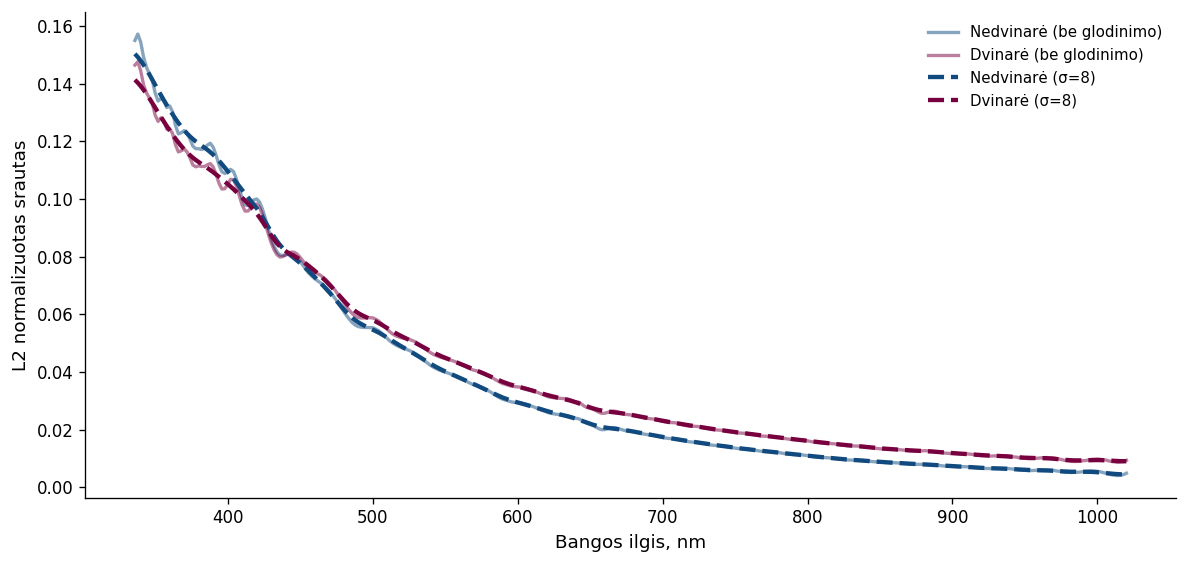

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    mean_0_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    alpha=0.5,
    linestyle="-",
    label="Nedvinarė (be glodinimo)",
    zorder=2,
)

ax.plot(
    wavelengths,
    mean_1_raw,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    alpha=0.5,
    linestyle="-",
    label="Dvinarė (be glodinimo)",
    zorder=2,
)

ax.plot(
    wavelengths,
    mean_0_sm,
    color=COLOR_RAW,
    linewidth=2.6,
    linestyle="--",
    label=f"Nedvinarė (σ={BEST_SIGMA:g})",
    zorder=3,
)

ax.plot(
    wavelengths,
    mean_1_sm,
    color=COLOR_SMOOTH,
    linewidth=2.6,
    linestyle="--",
    label=f"Dvinarė (σ={BEST_SIGMA:g})",
    zorder=3,
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)

plt.tight_layout()
fig.savefig(
    FIG_DIR / f"fig_class_mean_spectra_raw_vs_sigma{BEST_SIGMA:g}.svg",
    bbox_inches="tight",
)
plt.show()


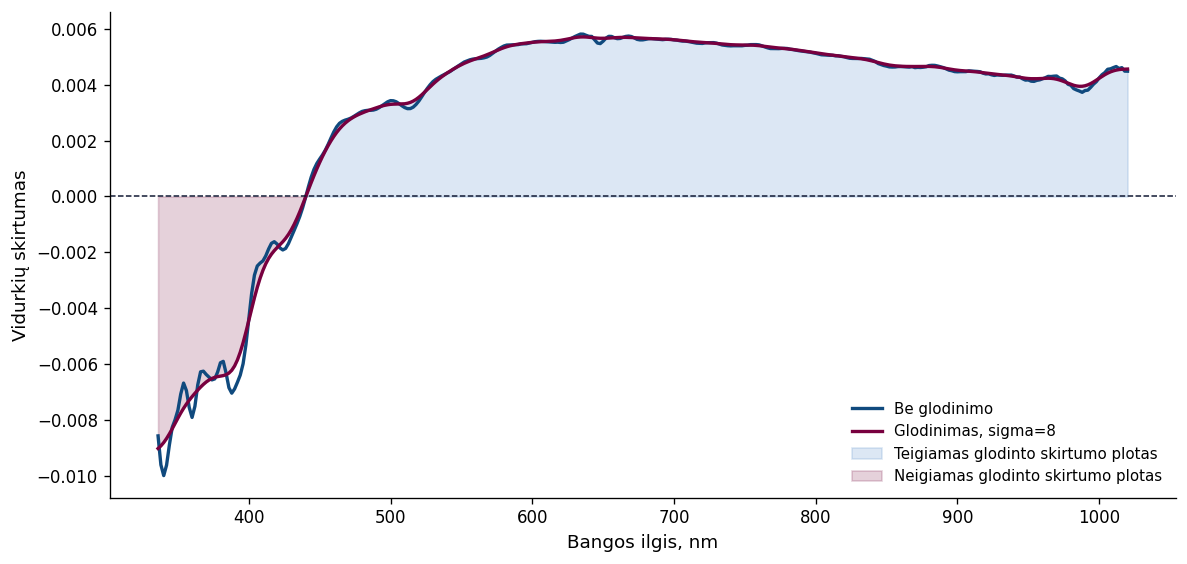

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    diff_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    label="Be glodinimo",
)

ax.plot(
    wavelengths,
    diff_sm,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    label=f"Glodinimas, sigma={BEST_SIGMA:g}",
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.fill_between(
    wavelengths,
    diff_sm,
    0,
    where=(diff_sm >= 0),
    color=COLOR_POS,
    alpha=0.22,
    interpolate=True,
    label="Teigiamas glodinto skirtumo plotas",
)

ax.fill_between(
    wavelengths,
    diff_sm,
    0,
    where=(diff_sm < 0),
    color=COLOR_NEG,
    alpha=0.18,
    interpolate=True,
    label="Neigiamas glodinto skirtumo plotas",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Vidurkių skirtumas")
ax.legend(frameon=False, loc="best")

apply_clean_axes(ax, add_grid=False)

fig.tight_layout()
fig.savefig(
    FIG_DIR / f"fig_mean_difference_raw_vs_sigma{BEST_SIGMA:g}.svg",
    bbox_inches="tight",
)
plt.show()


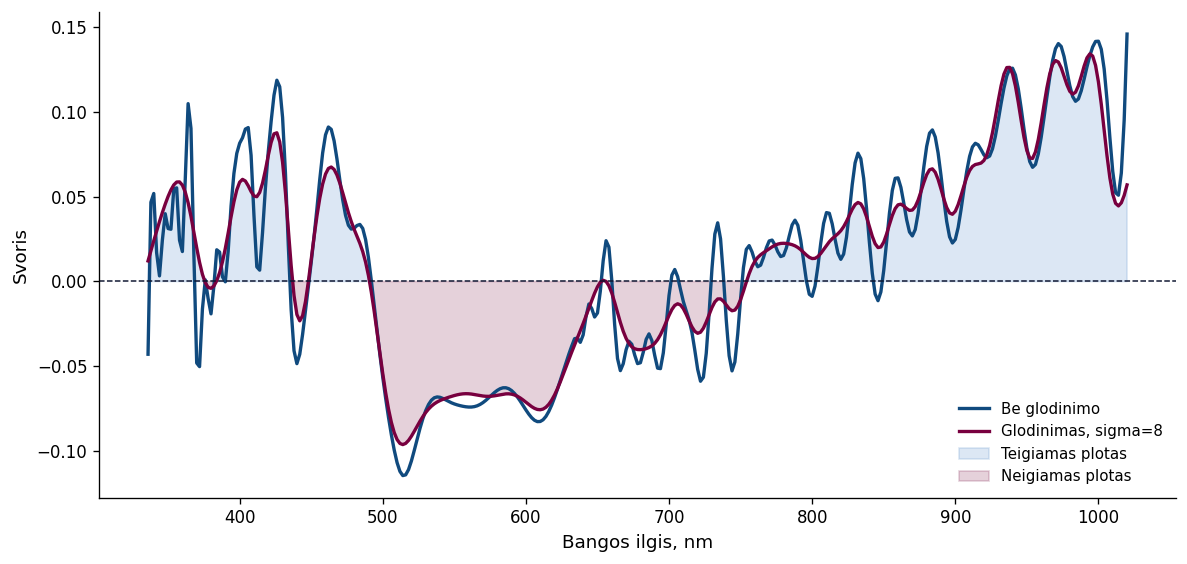

In [18]:
beta_logreg_raw = beta[(0.0, "logreg_l2")]
beta_logreg_sm = beta[(BEST_SIGMA, "logreg_l2")]

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    beta_logreg_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    label="Be glodinimo",
)

ax.plot(
    wavelengths,
    beta_logreg_sm,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    label=f"Glodinimas, sigma={BEST_SIGMA:g}",
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.fill_between(
    wavelengths,
    beta_logreg_sm,
    0,
    where=(beta_logreg_sm >= 0),
    color=COLOR_POS,
    alpha=0.22,
    interpolate=True,
    label="Teigiamas plotas",
)

ax.fill_between(
    wavelengths,
    beta_logreg_sm,
    0,
    where=(beta_logreg_sm < 0),
    color=COLOR_NEG,
    alpha=0.18,
    interpolate=True,
    label="Neigiamas plotas",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="lower right")

apply_clean_axes(ax, add_grid=False)

fig.tight_layout()
fig.savefig(
    FIG_DIR / f"fig_weights_logreg_l2_raw_vs_sigma{BEST_SIGMA:g}.svg",
    bbox_inches="tight",
)
plt.show()


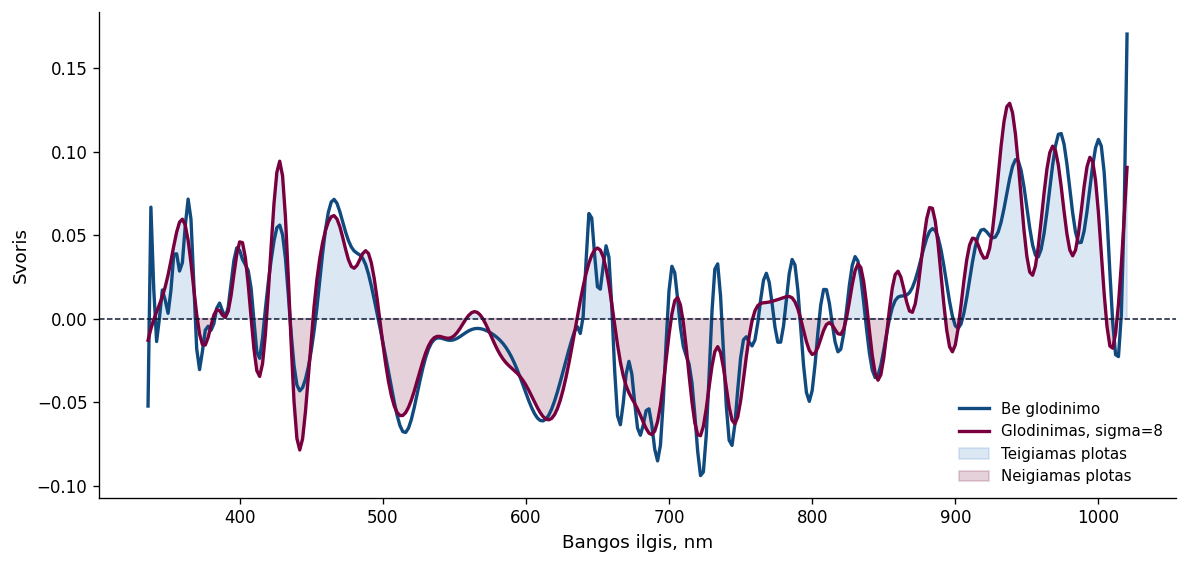

In [19]:
beta_svm_raw = beta[(0.0, "linear_svm")]
beta_svm_sm = beta[(BEST_SIGMA, "linear_svm")]

fig, ax = plt.subplots(figsize=(10, 4.8))

ax.plot(
    wavelengths,
    beta_svm_raw,
    color=COLOR_RAW,
    linewidth=2.0,
    label="Be glodinimo",
)

ax.plot(
    wavelengths,
    beta_svm_sm,
    color=COLOR_SMOOTH,
    linewidth=2.0,
    label=f"Glodinimas, sigma={BEST_SIGMA:g}",
)

ax.axhline(
    0,
    color=COLOR_DARK,
    linestyle="--",
    linewidth=0.9,
)

ax.fill_between(
    wavelengths,
    beta_svm_sm,
    0,
    where=(beta_svm_sm >= 0),
    color=COLOR_POS,
    alpha=0.22,
    interpolate=True,
    label="Teigiamas plotas",
)

ax.fill_between(
    wavelengths,
    beta_svm_sm,
    0,
    where=(beta_svm_sm < 0),
    color=COLOR_NEG,
    alpha=0.18,
    interpolate=True,
    label="Neigiamas plotas",
)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Svoris")
ax.legend(frameon=False, loc="lower right")

apply_clean_axes(ax, add_grid=False)

fig.tight_layout()
fig.savefig(
    FIG_DIR / f"fig_weights_svm_raw_vs_sigma{BEST_SIGMA:g}.svg",
    bbox_inches="tight",
)
plt.show()


 ## 14. Save outputs



 This section saves table outputs and the interpretability payload.

In [20]:
fold_path = OUT_DIR / "smoothing_fold_metrics.csv"
summary_path = OUT_DIR / "smoothing_summary.csv"
pretty_summary_path = OUT_DIR / "smoothing_summary_pretty.csv"
delta_path = OUT_DIR / "smoothing_delta_all_sigmas_minus_raw.csv"
wilcoxon_path = OUT_DIR / "smoothing_wilcoxon.csv"
payload_path = OUT_DIR / "smoothing_interpretability_payload.npz"

df_fold.to_csv(fold_path, index=False)
df_summary.to_csv(summary_path, index=False)
pretty_summary.to_csv(pretty_summary_path, index=False)
df_delta.to_csv(delta_path, index=False)
df_wilcoxon.to_csv(wilcoxon_path, index=False)

np.savez(
    payload_path,
    wavelengths=wavelengths,
    y=y,
    source_id=df_m["source_id"].to_numpy(),
    sigmas=np.array(SIGMAS, dtype=float),
    best_sigma=float(BEST_SIGMA),
    X_raw_l2=X_raw_l2,
    X_smoothed_l2=X_sm_l2,
    mean_0_raw=mean_0_raw,
    mean_1_raw=mean_1_raw,
    diff_raw=diff_raw,
    mean_0_smoothed=mean_0_sm,
    mean_1_smoothed=mean_1_sm,
    diff_smoothed=diff_sm,
    beta_logreg_raw=beta_logreg_raw,
    beta_logreg_smoothed=beta_logreg_sm,
    beta_svm_raw=beta_svm_raw,
    beta_svm_smoothed=beta_svm_sm,
)

print("Saved:")
print("-", fold_path)
print("-", summary_path)
print("-", pretty_summary_path)
print("-", delta_path)
print("-", wilcoxon_path)
print("-", payload_path)
print("-", FIG_DIR)


Saved:
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_fold_metrics.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_summary.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_summary_pretty.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_delta_all_sigmas_minus_raw.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_wilcoxon.csv
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing\smoothing_interpretability_payload.npz
- c:\Users\Lenovo\Documents\VDA\Bakalauras\Kodas\results\07_smoothing


 ## 15. Final view



 This compact view displays the main result tables.

In [21]:
print("\n=== SUMMARY ===")
display(pretty_summary)

print("\n=== DELTA: smoothed minus raw ===")
display(df_delta)

print("\n=== WILCOXON TESTS ===")
display(df_wilcoxon)



=== SUMMARY ===


,Sigma,Family,Method,F1 mean ± std,PR-AUC mean ± std,ROC-AUC mean ± std,Sensitivity mean ± std,Specificity mean ± std
0,0.0,Functional linear,Functional linear SVM,0.8066 ± 0.0300,0.8657 ± 0.0291,0.9151 ± 0.0197,0.8247 ± 0.0316,0.9453 ± 0.0149
1,4.0,Functional linear,Functional linear SVM,0.8064 ± 0.0283,0.8690 ± 0.0268,0.9178 ± 0.0181,0.8272 ± 0.0333,0.9443 ± 0.0141
2,6.0,Functional linear,Functional linear SVM,0.8086 ± 0.0294,0.8727 ± 0.0258,0.9209 ± 0.0172,0.8251 ± 0.0276,0.9464 ± 0.0150
3,8.0,Functional linear,Functional linear SVM,0.8121 ± 0.0290,0.8739 ± 0.0256,0.9215 ± 0.0171,0.8271 ± 0.0319,0.9479 ± 0.0152
4,10.0,Functional linear,Functional linear SVM,0.8079 ± 0.0272,0.8731 ± 0.0256,0.9204 ± 0.0174,0.8260 ± 0.0314,0.9456 ± 0.0154
5,12.0,Functional linear,Functional linear SVM,0.8088 ± 0.0276,0.8726 ± 0.0255,0.9193 ± 0.0173,0.8285 ± 0.0312,0.9453 ± 0.0152
6,0.0,Functional linear,Functional logistic regression (L2),0.8098 ± 0.0278,0.8650 ± 0.0280,0.9155 ± 0.0198,0.8292 ± 0.0329,0.9458 ± 0.0129
7,4.0,Functional linear,Functional logistic regression (L2),0.8094 ± 0.0257,0.8690 ± 0.0261,0.9189 ± 0.0184,0.8288 ± 0.0312,0.9457 ± 0.0117
8,6.0,Functional linear,Functional logistic regression (L2),0.8109 ± 0.0273,0.8708 ± 0.0257,0.9205 ± 0.0177,0.8278 ± 0.0307,0.9470 ± 0.0131
9,8.0,Functional linear,Functional logistic regression (L2),0.8112 ± 0.0263,0.8707 ± 0.0256,0.9202 ± 0.0179,0.8278 ± 0.0294,0.9472 ± 0.0113



=== DELTA: smoothed minus raw ===


,sigma,method,family,delta_pr_auc,delta_roc_auc,delta_sensitivity,delta_precision,delta_specificity,delta_accuracy,delta_f1,delta_youden_j
0,4.0,Functional linear SVM,Functional linear,0.003333,0.002654,0.002490,-0.002456,-9.334223e-04,-0.000249,-0.000125,0.001557
1,4.0,Functional logistic regression (L2),Functional linear,0.004000,0.003456,-0.000359,-0.000482,-4.277613e-05,-0.000107,-0.000336,-0.000402
2,4.0,weighted kNN + seuclidean,Distance-based functional,0.017934,0.009796,0.012003,0.017036,4.476090e-03,0.005968,0.014725,0.016479
3,6.0,Functional linear SVM,Functional linear,0.007080,0.005751,0.000352,0.003591,1.107176e-03,0.000959,0.002070,0.001459
4,6.0,Functional logistic regression (L2),Functional linear,0.005765,0.004984,-0.001441,0.003504,1.195573e-03,0.000675,0.001144,-0.000246
5,6.0,weighted kNN + seuclidean,Distance-based functional,0.020149,0.012310,0.007366,0.043464,1.303034e-02,0.011901,0.025651,0.020397
6,8.0,Functional linear SVM,Functional linear,0.008260,0.006419,0.002320,0.008730,2.568530e-03,0.002522,0.005495,0.004888
7,8.0,Functional logistic regression (L2),Functional linear,0.005642,0.004706,-0.001440,0.003657,1.417891e-03,0.000853,0.001403,-0.000022
8,8.0,weighted kNN + seuclidean,Distance-based functional,0.022094,0.013765,0.012376,0.038565,1.143604e-02,0.011616,0.025969,0.023812
9,10.0,Functional linear SVM,Functional linear,0.007462,0.005294,0.001244,0.001844,3.524125e-04,0.000533,0.001322,0.001596



=== WILCOXON TESTS ===


,sigma,method,metric,comparison,mean_raw,mean_smoothed,mean_delta,wilcoxon_statistic,p_value,statistically_significant,direction
0,4.0,Functional linear SVM,f1,sigma=4 vs raw,0.806558,0.806433,-0.000125,521.0,8.312920e-01,False,decreased
1,4.0,Functional linear SVM,pr_auc,sigma=4 vs raw,0.865662,0.868995,0.003333,91.0,4.057499e-09,True,improved
2,4.0,Functional logistic regression (L2),f1,sigma=4 vs raw,0.809755,0.809419,-0.000336,546.0,6.666321e-01,False,decreased
3,4.0,Functional logistic regression (L2),pr_auc,sigma=4 vs raw,0.865020,0.869020,0.004000,51.0,6.337864e-11,True,improved
4,4.0,weighted kNN + seuclidean,f1,sigma=4 vs raw,0.773768,0.788494,0.014725,199.0,3.902013e-05,True,improved
5,4.0,weighted kNN + seuclidean,pr_auc,sigma=4 vs raw,0.808304,0.826237,0.017934,40.0,1.544898e-11,True,improved
6,6.0,Functional linear SVM,f1,sigma=6 vs raw,0.806558,0.808628,0.002070,509.0,2.186624e-01,False,improved
7,6.0,Functional linear SVM,pr_auc,sigma=6 vs raw,0.865662,0.872742,0.007080,45.0,2.994405e-11,True,improved
8,6.0,Functional logistic regression (L2),f1,sigma=6 vs raw,0.809755,0.810899,0.001144,527.0,6.953982e-01,False,improved
9,6.0,Functional logistic regression (L2),pr_auc,sigma=6 vs raw,0.865020,0.870786,0.005765,35.0,7.656098e-12,True,improved
